<a href="https://colab.research.google.com/github/ashwiniv07/Journal-paper--DDoS-GT-DL-/blob/main/Dataset3_UNSW_UB15_without_resampling.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Import Library

In [ ]:
import os
import pandas as pd
import numpy as np
import gc
from sklearn.preprocessing import LabelEncoder, StandardScaler
import shutil
from google.colab import drive
from collections import Counter
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import pairwise_distances
from scipy import stats
import warnings
warnings.filterwarnings('ignore')
import matplotlib.pyplot as plt
from sklearn.neighbors import LocalOutlierFactor
from sklearn.decomposition import PCA
from mpl_toolkits.mplot3d import Axes3D
drive.mount('/content/drive')
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input, Conv1D, MaxPooling1D, Bidirectional, GRU, Dense,
    Dropout, Flatten, Attention, Permute, Multiply, Lambda, GlobalAveragePooling1D
)
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.optimizers import Adam
import tensorflow.keras.backend as K
import tensorflow as tf
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, f1_score, roc_curve, auc
import seaborn as sns
from tensorflow.keras.utils import to_categorical

Mounted at /content/drive


## Step 1: Dataset Collection

In [ ]:
path = '/content/drive/MyDrive/project ashwini/UNSW_NB15'
destination_folder = '/content/Dataset'
if not os.path.exists(destination_folder):
    os.makedirs(destination_folder)
for filename in os.listdir(path):
    source_file = os.path.join(path, filename)
    destination_file = os.path.join(destination_folder, filename)
    if os.path.isfile(source_file):
        shutil.copy2(source_file, destination_file)
path = destination_folder

## Step 2: Labelling the Dataset as Fraud-only, DDoS-only, Fraud-under-DDoS and Benign

In [ ]:

path = '/content/drive/MyDrive/project ashwini/UNSW_NB15'
all_files = [os.path.join(dirname, filename) for dirname, _, filenames in os.walk(path)
             for filename in filenames if filename.endswith('.csv')]
common_columns = None
file_columns = {}
for file_path in all_files:
    try:
        df_sample = pd.read_csv(file_path, nrows=0)
        file_columns[file_path] = set(df_sample.columns)
        if common_columns is None:
            common_columns = set(df_sample.columns)
        else:
            common_columns = common_columns.intersection(set(df_sample.columns))
    except Exception as e:
        print(f"Error reading headers from {file_path}: {e}")

if common_columns:
    all_dfs = []
    for file_path in all_files:
        try:
            df = pd.read_csv(file_path, usecols=list(common_columns))
            all_dfs.append(df)
        except Exception as e:
            print(f"Error reading {file_path}: {e}")

    if all_dfs:
        combined_df = pd.concat(all_dfs, ignore_index=True)

    else:
        print("No dataframes to concatenate.")
else:
    print("Cannot concatenate due to inconsistent or missing columns.")
def relabel_attack_categories(df):

    df_relabeled = df.copy()

    fraud_attacks = ['Backdoor', 'Exploits', 'Shellcode', 'Reconnaissance']

    ddos_attacks = ['DoS', 'Fuzzers', 'Generic']

    potential_hybrid = ['Analysis', 'Worms']
    benign = ['Normal']

    def categorize_attack(row):
        attack_cat = row['attack_cat']

        if attack_cat in benign:
            return 'Benign'
        is_fraud = attack_cat in fraud_attacks
        is_ddos = attack_cat in ddos_attacks
        is_hybrid = attack_cat in potential_hybrid

        if is_fraud and not is_ddos:
            return 'Fraud-only'
        elif is_ddos and not is_fraud:
            return 'DDoS-only'
        elif (is_fraud and is_ddos) or is_hybrid:
            return categorize_hybrid_attack(row)
        else:

            return 'Fraud-under-DDoS'

    def categorize_hybrid_attack(row):
        high_rate = row['rate'] > df['rate'].quantile(0.75)
        high_packets = (row['spkts'] + row['dpkts']) > (df['spkts'] + df['dpkts']).quantile(0.75)
        high_bytes = (row['sbytes'] + row['dbytes']) > (df['sbytes'] + df['dbytes']).quantile(0.75)

        multiple_connections = row['ct_srv_src'] > df['ct_srv_src'].quantile(0.75)

        ddos_indicators = sum([high_rate, high_packets, high_bytes])
        fraud_indicators = multiple_connections

        if ddos_indicators >= 2 and fraud_indicators >= 1:
            return 'Fraud-under-DDoS'
        elif ddos_indicators >= 2:
            return 'DDoS-only'
        else:
            return 'Fraud-only'

    df_relabeled['Final_label'] = df_relabeled.apply(categorize_attack, axis=1)

    return df_relabeled

def relabel_simple(df):

    df_simple = df.copy()

    mapping = {
        'Normal': 'Benign',
        'Reconnaissance': 'Fraud-only',
        'Backdoor': 'Fraud-only',
        'DoS': 'DDoS-only',
        'Exploits': 'Fraud-only',
        'Analysis': 'Fraud-under-DDoS',
        'Fuzzers': 'DDoS-only',
        'Worms': 'Fraud-under-DDoS',
        'Shellcode': 'Fraud-only',
        'Generic': 'DDoS-only'
    }

    df_simple['Final_label'] = df_simple['attack_cat'].map(mapping)

    if df_simple['Final_label'].isna().any():
        unmapped = df_simple[df_simple['Final_label'].isna()]['attack_cat'].unique()
        df_simple['Final_label'] = df_simple['Final_label'].fillna('Fraud-under-DDoS')

    return df_simple

def process_dataframe(df, method='simple'):
    if method == 'simple':
        return relabel_simple(df)
    else:
        return relabel_attack_categories(df)

def verify_relabeling(df_processed):
    required_labels = ['Fraud-only', 'DDoS-only', 'Fraud-under-DDoS', 'Benign']
    missing_labels = set(required_labels) - set(df_processed['Final_label'].unique())
    return df_processed
df_processed = process_dataframe(df, method='simple')
df_verified = verify_relabeling(df_processed)

df_verified.to_csv('unsw18.csv', index=False)

## Step 3: Apply Preprocessing such as

### 1	Drop irrelevant columns	Reason: Remove non-useful or redundant information
### 2	Drop constant columns	Reason: Eliminate features with no variability
### 3	Encode labels	Reason: Convert categorical target to numeric
### 4	Handle missing values	Ensure no NaN values
### 5	Normalize features	Standardize numeric input features
### 6	Feature-label split	Prepare for training/evaluation

In [ ]:
df = pd.read_csv('/content/unsw18.csv')
drop_cols = ['timestamp', 'window', 'fraud_score', 'is_ddos', 'Label','attack_cat','label']
df.drop(columns=drop_cols, inplace=True, errors='ignore')
df.dropna(inplace=True)
df.reset_index(drop=True, inplace=True)
constant_cols = df.columns[df.nunique() <= 1]
df.drop(columns=constant_cols, inplace=True)
le = LabelEncoder()
df['Label_encoded'] = le.fit_transform(df['Final_label'])
label_map = dict(zip(le.classes_, le.transform(le.classes_)))
df.dropna(inplace=True)
df.reset_index(drop=True, inplace=True)
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()
numeric_cols.remove('Label_encoded')
scaler = StandardScaler()
df[numeric_cols] = scaler.fit_transform(df[numeric_cols])
X = df[numeric_cols].values
y = to_categorical(df['Label_encoded'].values)
X = X.reshape((X.shape[0], 1, X.shape[1]))

## Step 4: Train-test split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## Step 4: Build Proposed CNN-BiGRU Model

In [ ]:
def build_model(input_shape, num_classes):
    inputs = Input(shape=input_shape)
    x = Conv1D(filters=64, kernel_size=1, activation='relu')(inputs)
    x = MaxPooling1D(pool_size=1)(x)
    x = Bidirectional(GRU(64, return_sequences=True))(x)
    x = GlobalAveragePooling1D()(x)
    x = Dense(64, activation='relu')(x)
    x = Dropout(0.3)(x)
    outputs = Dense(num_classes, activation='softmax')(x)
    model = Model(inputs, outputs)
    model.compile(optimizer=Adam(learning_rate=0.001), loss='categorical_crossentropy', metrics=['accuracy'])
    return model

## Step 5: Train Proposed Model

In [ ]:
model = build_model(input_shape=X_train.shape[1:], num_classes=y_train.shape[1])
history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=150,
    batch_size=32,
    verbose=1
)

Epoch 1/150
4384/4384 ━━━━━━━━━━━━━━━━━━━━ 34s 7ms/step - accuracy: 0.8022 - loss: 0.4455 - val_accuracy: 0.8474 - val_loss: 0.3403
Epoch 2/150
4384/4384 ━━━━━━━━━━━━━━━━━━━━ 26s 6ms/step - accuracy: 0.8429 - loss: 0.3472 - val_accuracy: 0.8533 - val_loss: 0.3229
Epoch 3/150
4384/4384 ━━━━━━━━━━━━━━━━━━━━ 26s 6ms/step - accuracy: 0.8515 - loss: 0.3267 - val_accuracy: 0.8605 - val_loss: 0.3074
Epoch 4/150
4384/4384 ━━━━━━━━━━━━━━━━━━━━ 27s 6ms/step - accuracy: 0.8550 - loss: 0.3197 - val_accuracy: 0.8627 - val_loss: 0.2994
Epoch 5/150
4384/4384 ━━━━━━━━━━━━━━━━━━━━ 26s 6ms/step - accuracy: 0.8570 - loss: 0.3089 - val_accuracy: 0.8527 - val_loss: 0.3147
Epoch 6/150
4384/4384 ━━━━━━━━━━━━━━━━━━━━ 26s 6ms/step - accuracy: 0.8613 - loss: 0.3002 - val_accuracy: 0.8649 - val_loss: 0.2935
Epoch 7/150
4384/4384 ━━━━━━━━━━━━━━━━━━━━ 41s 6ms/step - accuracy: 0.8602 - loss: 0.2992 - val_accuracy: 0.8634 - val_loss: 0.2907
Epoch 8/150
4384/4384 ━━━━━━━━━━━━━━━━━━━━ 28s 6ms/step - accuracy: 0.8645 -

## Step 6: Evaluate Proposed Model

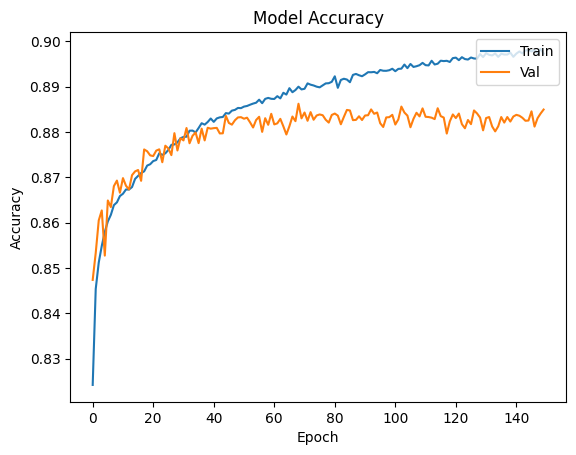

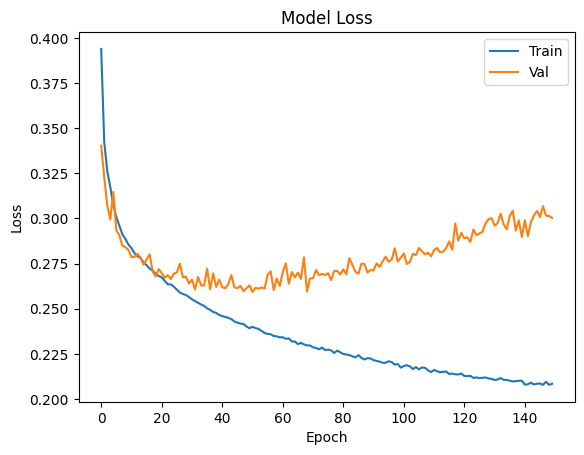

1096/1096 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step

 Classification Report:
                  precision    recall  f1-score   support

          Benign       0.98      0.98      0.98     11169
       DDoS-only       0.95      0.79      0.86     14019
      Fraud-only       0.74      0.95      0.83      9463
Fraud-under-DDoS       0.71      0.19      0.30       418

        accuracy                           0.88     35069
       macro avg       0.84      0.73      0.74     35069
    weighted avg       0.90      0.88      0.88     35069



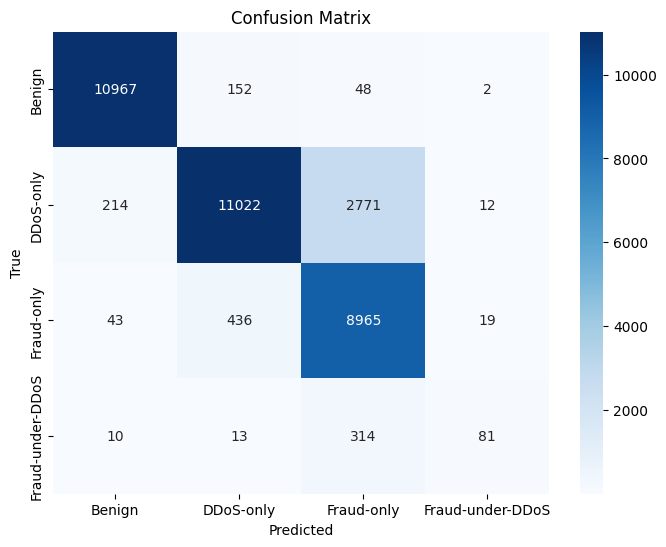

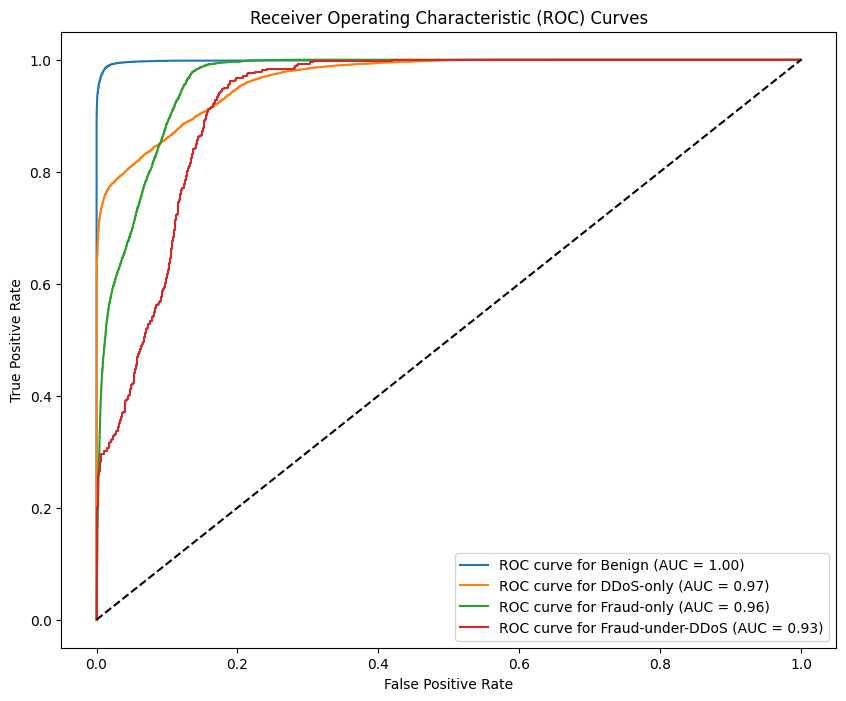


 AUC Score (OvR): 0.9638


In [ ]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Val'], loc='upper right')
plt.show()
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Val'], loc='upper right')
plt.show()
target_names = [str(c) for c in le.classes_]

y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = np.argmax(y_test, axis=1)


print("\n Classification Report:")
print(classification_report(y_true, y_pred, target_names=target_names, zero_division=0))


cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=target_names, yticklabels=target_names)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

plt.figure(figsize=(10, 8))
for i in range(len(target_names)):
    fpr, tpr, _ = roc_curve(y_test[:, i], y_pred_probs[:, i])
    plt.plot(fpr, tpr, label=f'ROC curve for {target_names[i]} (AUC = {auc(fpr, tpr):.2f})')

plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curves')
plt.legend(loc='lower right')
plt.show()

try:
    auc_score = roc_auc_score(y_test, y_pred_probs, multi_class="ovr")
    print(f"\n AUC Score (OvR): {auc_score:.4f}")
except Exception as e:
    print(" Could not compute AUC:", e)


# Step 7: Implementation of Proposed CADE-GF

## Step 7 (a): Attacker Utility Function

In [ ]:
def attacker_utility(prob_fraud, threshold=0.5, cost_detected=1.0, reward_evade=5.0, cost_false_positive=0.5):
    if prob_fraud >= threshold:
        return -cost_detected * prob_fraud
    else:
        return reward_evade * (1 - prob_fraud) - cost_false_positive * prob_fraud

## Step 7 (b): Threshold Search Resolution Function

In [ ]:
def optimal_threshold(pred_probs, true_labels):
    thresholds = np.linspace(0.1, 0.9, 81)
    best_thresh = 0.5
    min_utility = float('inf')

    for t in thresholds:
        evasion_utilities = [
            attacker_utility(prob, threshold=t, cost_detected=2.0)
            for prob, true in zip(pred_probs, true_labels) if true != 0
        ]
        if evasion_utilities:
            avg_utility = np.mean(evasion_utilities)
            if avg_utility < min_utility:
                min_utility = avg_utility
                best_thresh = t
    return best_thresh

## Step 7 (c): Evasion Attack function

In [ ]:
def simulate_evasion(X, numeric_cols_indices, epsilon=0.1):
    X_evaded = X.copy()
    X_reshaped = X_evaded.reshape(X_evaded.shape[0], X_evaded.shape[2])
    noise = np.random.normal(0, epsilon, size=(X_reshaped.shape[0], len(numeric_cols_indices)))
    X_reshaped[:, numeric_cols_indices] += noise
    X_evaded = X_reshaped.reshape(X_evaded.shape)
    return X_evaded

## Step 8: Evalaution of CADE-GF
### Print Evalaution Metrics (AUC) Before/After

In [ ]:
feature_names = numeric_cols
continuous_traffic_features = [
    'Flow Duration', 'Total Fwd Packets', 'Total Backward Packets',
    'Total Length of Fwd Packets', 'Total Length of Bwd Packets',
    'Fwd Packet Length Max', 'Fwd Packet Length Min', 'Fwd Packet Length Mean',
    'Bwd Packet Length Max', 'Bwd Packet Length Min', 'Bwd Packet Length Mean',
    'Flow Bytes/s', 'Flow Packets/s', 'Flow IAT Mean', 'Flow IAT Std',
    'Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Std', 'Bwd IAT Total',
    'Bwd IAT Mean', 'Bwd IAT Std', 'Fwd Header Length', 'Bwd Header Length',
    'Fwd Packets/s', 'Bwd Packets/s', 'Min Packet Length', 'Max Packet Length',
    'Packet Length Mean', 'Packet Length Std', 'Packet Length Variance',
    'Down/Up Ratio', 'Average Packet Size', 'Avg Fwd Segment Size',
    'Avg Bwd Segment Size', 'Fwd Header Length.1', 'Fwd Avg Bytes/Bulk',
    'Fwd Avg Packets/Bulk', 'Fwd Avg Bulk Rate', 'Bwd Avg Bytes/Bulk',
    'Bwd Avg Packets/Bulk', 'Bwd Avg Bulk Rate', 'Subflow Fwd Packets',
    'Subflow Fwd Bytes', 'Subflow Bwd Packets', 'Subflow Bwd Bytes',
    'Init_Win_bytes_forward', 'Init_Win_bytes_backward', 'act_data_pkt_fwd',
    'min_seg_size_forward', 'Active Mean', 'Active Std', 'Active Max',
    'Active Min', 'Idle Mean', 'Idle Std', 'Idle Max', 'Idle Min'
]
continuous_features_to_perturb = [f for f in continuous_traffic_features if f in feature_names]
continuous_feature_indices = [feature_names.index(f) for f in continuous_features_to_perturb if f in feature_names]
pred_probs = model.predict(X_test)
fraud_probs = pred_probs[:, 1]
y_true = np.argmax(y_test, axis=1)
opt_thresh = optimal_threshold(fraud_probs, y_true)
print(f"Optimal threshold: {opt_thresh:.3f}")
y_clean = (fraud_probs >= opt_thresh).astype(int)
X_evaded = simulate_evasion(X_test, continuous_feature_indices, epsilon=0.1)
fraud_probs_evaded = model.predict(X_evaded)[:, 1]
y_evaded = (fraud_probs_evaded >= opt_thresh).astype(int)
try:
    auc_clean = roc_auc_score(y_test, model.predict(X_test), multi_class='ovr')
    auc_evade = roc_auc_score(y_test, model.predict(X_evaded), multi_class='ovr')
    print(f"AUC (clean): {auc_clean:.4f}")
    print(f"AUC (evaded): {auc_evade:.4f}")
    print(f"AUC degradation: {auc_clean - auc_evade:.4f}")
    evasion_success = np.mean((y_clean == 1) & (y_evaded == 0))
    print(f"Evasion success rate: {evasion_success:.4f}")
except Exception as e:
    print(f"Evaluation error: {e}")

1096/1096 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step
Optimal threshold: 0.100
1096/1096 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step
1096/1096 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step
1096/1096 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step
AUC (clean): 0.9638
AUC (evaded): 0.9638
AUC degradation: 0.0000
Evasion success rate: 0.0000
